
# Embedding Model Benchmark — MTEB, Semantic Search & RAG

This notebook is a practical benchmark framework for comparing embedding models for **semantic search and RAG**.

## Deliverables covered

- Explain MTEB and common embedding evaluation tasks.
- Explain how embedding models are scored and ranked.
- Programmatically evaluate Sentence-Transformers models on a target dataset.
- Compare at least two distinct embedding models on accuracy and operational metrics.
- Measure embedding latency and memory footprint locally.
- Analyze model-size vs retrieval-quality trade-offs.
- Produce a quantitative benchmark report and a data-backed recommendation.

> **Important:** MTEB leaderboard values are published benchmark results and should not be confused with results from your own domain dataset. This notebook therefore includes a reproducible local benchmark plus an optional MTEB evaluation section.



# 1. Why embedding-model selection matters

An embedding model converts text into a vector:

\[
f(text) \rightarrow \mathbf{v} \in \mathbb{R}^{d}
\]

Semantic search compares the query vector with candidate document vectors using a similarity function such as cosine similarity.

A model can be excellent on a public benchmark and still perform poorly on a specific RAG corpus because:

- terminology differs from benchmark data,
- queries may be domain-specific,
- documents may be long or highly structured,
- multilingual behavior may matter,
- the production chunking strategy changes the retrieval problem,
- latency and memory constraints can change the best production choice.

Therefore, use **public benchmarks for general capability** and a **domain-specific benchmark for final selection**.



# 2. MTEB overview

The **Massive Text Embedding Benchmark (MTEB)** is a broad benchmark suite for evaluating text embedding models across multiple tasks and datasets.

Common task families include:

| Task | What it measures | Typical metric |
|---|---|---|
| Retrieval | Finding relevant documents for a query | nDCG@k / Recall@k |
| STS | Semantic similarity between text pairs | Spearman correlation |
| Classification | Using embeddings for classification | Accuracy / F1 |
| Clustering | Grouping semantically related texts | V-measure / clustering metrics |
| Pair Classification | Predicting relationships between text pairs | Accuracy / F1 |
| Reranking | Ordering candidate passages | ranking metrics |
| Summarization | Comparing generated/summary text representations | task-specific metrics |

### How leaderboard scores should be interpreted

MTEB reports results **per task/dataset** and aggregates them into broader task-category or overall scores depending on the benchmark/leaderboard presentation.

A higher score generally means better performance on that benchmark's metric, but scores from different task families are not necessarily interchangeable.

**Do not select a model from a single headline score alone.**

For a semantic-search/RAG application, retrieval results should receive the greatest weight, followed by domain relevance, latency, memory, and cost.

### Important caveat

Leaderboard results depend on:

- model version
- evaluation protocol
- prompt/instruction formatting
- dataset version
- pooling/normalization
- hardware/software
- whether the model is permitted to use task-specific instructions

Always record the exact model and evaluation configuration when reproducing a result.


In [1]:

# 3. Imports and environment

from pathlib import Path
import time
import gc
import platform
import subprocess
import sys
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())


Python: 3.14.6
Platform: Windows-11-10.0.26200-SP0



# 4. Install optional dependencies

Run this cell when the required packages are not already installed.

- `sentence-transformers` — local embedding models.
- `datasets` — benchmark datasets.
- `mteb` — MTEB evaluation framework.
- `psutil` — process memory measurement.

For OpenAI embeddings, also install the official OpenAI Python SDK and configure authentication outside the notebook (for example, through an environment variable).


In [2]:

# Uncomment if needed:
# %pip install -U sentence-transformers datasets mteb psutil openai

print("Optional dependency installation cell ready.")


Optional dependency installation cell ready.



# 5. Define the benchmark dataset

For a RAG/semantic-search benchmark, a compact local dataset should contain:

- `query`
- one or more positive/relevant documents
- optionally, negative documents

This notebook includes a small domain-neutral dataset so it can run without downloading a large benchmark.

For production evaluation, replace it with your real search queries and expert-verified relevant passages.


In [3]:

benchmark = pd.DataFrame([
    {
        "query_id": "q1",
        "query": "Why is retrieval quality important in RAG systems?",
        "positive": "Retrieval quality is critical because the language model can only use evidence that is passed into its context.",
    },
    {
        "query_id": "q2",
        "query": "What are the drawbacks of very large text chunks?",
        "positive": "Very large chunks can contain irrelevant information and reduce retrieval precision.",
    },
    {
        "query_id": "q3",
        "query": "How do embedding models support semantic search?",
        "positive": "Embedding models map semantically related text into nearby numerical vectors, enabling similarity search.",
    },
    {
        "query_id": "q4",
        "query": "What is the purpose of a vector database?",
        "positive": "A vector database indexes embeddings and performs nearest-neighbor search over vector representations.",
    },
    {
        "query_id": "q5",
        "query": "How should embedding models be selected for production?",
        "positive": "Production selection should balance retrieval quality, latency, memory, cost, and domain performance.",
    },
    {
        "query_id": "q6",
        "query": "What does MTEB evaluate?",
        "positive": "MTEB evaluates text embedding models across retrieval, semantic similarity, classification, clustering, and other tasks.",
    },
    {
        "query_id": "q7",
        "query": "Why can a high leaderboard model perform poorly on a company knowledge base?",
        "positive": "Public benchmark performance may not transfer to domain-specific terminology, document structure, and query distributions.",
    },
    {
        "query_id": "q8",
        "query": "Why should latency be measured alongside embedding accuracy?",
        "positive": "A highly accurate model may be unsuitable if its inference latency or memory footprint violates production requirements.",
    },
])

# Candidate corpus intentionally contains both relevant and distractor passages.
candidate_docs = [
    benchmark.loc[i, "positive"] for i in range(len(benchmark))
] + [
    "Project management includes milestones, owners, delivery dates, risks, and status meetings.",
    "Database backups should be encrypted and periodically tested for restoration.",
    "A web application's user interface should be responsive across common screen sizes.",
    "Software testing can include unit tests, integration tests, regression tests, and end-to-end tests.",
    "Cloud infrastructure can be monitored with metrics, logs, traces, and alerting systems.",
    "A product roadmap can communicate planned features and strategic priorities.",
]

print("Queries:", len(benchmark))
print("Candidate documents:", len(candidate_docs))


Queries: 8
Candidate documents: 14



# 6. Evaluation metrics

For semantic search, common metrics include:

### Recall@k

\[
Recall@k = \frac{\text{relevant documents retrieved in top-k}}
{\text{all relevant documents}}
\]

In this notebook each query has one positive passage, so Recall@k becomes a hit-rate style measure.

### MRR@k

\[
RR_q = \frac{1}{rank(\text{first relevant result})}
\]

and:

\[
MRR@k = \frac{1}{N}\sum_q RR_q
\]

MRR strongly rewards putting the first relevant result near the top.

### nDCG@k

Normalized Discounted Cumulative Gain accounts for relevance and ranking position. It is particularly useful when queries can have multiple relevance grades.

For production RAG, it is useful to report **Recall@k, MRR@k, and/or nDCG@k**, rather than relying on only one number.


In [4]:

def reciprocal_rank(relevant_flags):
    for rank, is_relevant in enumerate(relevant_flags, start=1):
        if is_relevant:
            return 1.0 / rank
    return 0.0


def evaluate_rankings(rankings, positive_texts, ks=(1, 3, 5)):
    rows = []

    for i, ranking in enumerate(rankings):
        positive = positive_texts[i]
        row = {"query_id": benchmark.iloc[i]["query_id"]}

        for k in ks:
            top_k = ranking[:k]
            hits = sum(doc == positive for doc in top_k)
            row[f"Recall@{k}"] = 1.0 if hits > 0 else 0.0

        row["MRR@5"] = reciprocal_rank(
            [doc == positive for doc in ranking[:5]]
        )
        rows.append(row)

    result = pd.DataFrame(rows)
    summary = result.drop(columns=["query_id"]).mean()
    return result, summary


print("Evaluation metrics ready.")


Evaluation metrics ready.



# 7. Baseline: TF-IDF

A lexical baseline helps answer an important question:

> Is the embedding model actually improving semantic retrieval over simple keyword matching?

This baseline is not an embedding model, but it provides a useful lower-cost reference point.


In [5]:

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    sublinear_tf=True
)

doc_matrix = tfidf.fit_transform(candidate_docs)
query_matrix = tfidf.transform(benchmark["query"])

tfidf_rankings = []
for q_vec in query_matrix:
    scores = cosine_similarity(q_vec, doc_matrix).ravel()
    order = np.argsort(-scores)
    tfidf_rankings.append([candidate_docs[j] for j in order])

tfidf_per_query, tfidf_summary = evaluate_rankings(
    tfidf_rankings,
    benchmark["positive"].tolist()
)

print("TF-IDF baseline:")
display(tfidf_summary.to_frame("score"))


TF-IDF baseline:


,score
Recall@1,0.500
Recall@3,0.625
Recall@5,0.875
MRR@5,0.625



# 8. Sentence-Transformers embedding benchmark

We compare two distinct open-source embedding models by default:

- `sentence-transformers/all-MiniLM-L6-v2` — compact and fast.
- `BAAI/bge-small-en-v1.5` — a compact BGE retrieval-oriented model.

You can add larger models such as `BAAI/bge-base-en-v1.5`, `intfloat/e5-base-v2`, or another model appropriate to your use case.

**Model availability:** the model files may need to be downloaded on first use. If the environment has no network access, use models already cached locally.


In [16]:

MODEL_NAMES = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "BAAI/bge-small-en-v1.5",
    # "intfloat/e5-base-v2",
    # "BAAI/bge-base-en-v1.5",
]

try:
    from sentence_transformers import SentenceTransformer
    st_available = True
except ImportError:
    st_available = False
    print("sentence-transformers is not installed.")
    print("Install with: pip install -U sentence-transformers")


In [17]:

def benchmark_sentence_transformer(
    model_name,
    queries,
    documents,
    positives,
    batch_size=32,
    warmup=True,
):
    model = SentenceTransformer(model_name)

    # Encode documents once, as would normally be done during indexing.
    doc_start = time.perf_counter()
    doc_embeddings = model.encode(
        documents,
        batch_size=batch_size,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    doc_time = time.perf_counter() - doc_start

    # Warm-up removes some first-call overhead from the query latency estimate.
    if warmup:
        _ = model.encode(
            [queries[0]],
            normalize_embeddings=True,
            show_progress_bar=False,
        )

    query_start = time.perf_counter()
    query_embeddings = model.encode(
        queries,
        batch_size=batch_size,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    query_time = time.perf_counter() - query_start

    query_embeddings = np.asarray(query_embeddings)
    doc_embeddings = np.asarray(doc_embeddings)

    rankings = []
    for q_vec in query_embeddings:
        scores = q_vec @ doc_embeddings.T
        order = np.argsort(-scores)
        rankings.append([documents[j] for j in order])

    per_query, summary = evaluate_rankings(rankings, positives)

    # Approximate resident process memory; this is not GPU VRAM.
    memory_mb = np.nan
    try:
        import psutil
        process = psutil.Process(os.getpid())
        memory_mb = process.memory_info().rss / (1024 ** 2)
    except Exception:
        pass

    # Model parameter count if exposed.
    parameters_m = np.nan
    try:
        parameters_m = sum(p.numel() for p in model.parameters()) / 1e6
    except Exception:
        pass

    result = {
        "model": model_name,
        "parameters_M": parameters_m,
        "embedding_dim": int(query_embeddings.shape[1]),
        "index_encoding_seconds": doc_time,
        "query_encoding_seconds": query_time,
        "query_latency_ms_per_query": (query_time / len(queries)) * 1000,
        "process_memory_MB": memory_mb,
        **summary.to_dict(),
    }

    return model, result, per_query, rankings


embedding_results = []
embedding_per_query = {}
embedding_models = {}

if st_available:
    for model_name in MODEL_NAMES:
        try:
            model, result, per_query, rankings = benchmark_sentence_transformer(
                model_name,
                benchmark["query"].tolist(),
                candidate_docs,
                benchmark["positive"].tolist(),
            )
            embedding_results.append(result)
            embedding_per_query[model_name] = per_query
            embedding_models[model_name] = model
            print(f"Completed: {model_name}")
        except Exception as exc:
            print(f"Could not benchmark {model_name}: {exc}")

embedding_summary = pd.DataFrame(embedding_results)

if not embedding_summary.empty:
    display(embedding_summary)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6263.33it/s]


Completed: sentence-transformers/all-MiniLM-L6-v2


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6227.18it/s]


Completed: BAAI/bge-small-en-v1.5


,model,parameters_M,embedding_dim,index_encoding_seconds,query_encoding_seconds,query_latency_ms_per_query,process_memory_MB,Recall@1,Recall@3,Recall@5,MRR@5
0,sentence-transformers/all-MiniLM-L6-v2,22.713216,384,0.051714,0.024688,3.085938,802.675781,0.750,1.000,1.0,0.875000
1,BAAI/bge-small-en-v1.5,33.360000,384,0.092690,0.045658,5.707238,893.093750,0.625,0.875,1.0,0.754167



# 9. Add an OpenAI embedding model

OpenAI embeddings can be benchmarked with the same evaluation framework, but they are API-based rather than local Sentence-Transformers models.

The following adapter is intentionally optional. It requires an API key and network access.

For a fair comparison, measure:

- retrieval metric on the same queries/documents
- API embedding latency
- token usage/cost
- caching behavior
- index size

Do not compare raw local CPU latency against remote API latency without clearly labeling the difference.


In [18]:

def benchmark_openai_embedding(
    model_name="text-embedding-3-small",
    api_key=None,
):
    try:
        from openai import OpenAI
    except ImportError:
        raise ImportError("Install the OpenAI SDK with: pip install -U openai")

    client = OpenAI(api_key=api_key or os.environ.get("OPENAI_API_KEY"))

    if not (api_key or os.environ.get("OPENAI_API_KEY")):
        raise ValueError("Set OPENAI_API_KEY or pass api_key explicitly.")

    # Documents: one API request for all candidate passages.
    doc_start = time.perf_counter()
    doc_response = client.embeddings.create(
        model=model_name,
        input=candidate_docs,
    )
    doc_time = time.perf_counter() - doc_start

    query_start = time.perf_counter()
    query_response = client.embeddings.create(
        model=model_name,
        input=benchmark["query"].tolist(),
    )
    query_time = time.perf_counter() - query_start

    doc_embeddings = np.asarray([x.embedding for x in doc_response.data])
    query_embeddings = np.asarray([x.embedding for x in query_response.data])

    doc_embeddings /= np.linalg.norm(doc_embeddings, axis=1, keepdims=True)
    query_embeddings /= np.linalg.norm(query_embeddings, axis=1, keepdims=True)

    rankings = []
    for q_vec in query_embeddings:
        scores = q_vec @ doc_embeddings.T
        order = np.argsort(-scores)
        rankings.append([candidate_docs[j] for j in order])

    per_query, summary = evaluate_rankings(
        rankings,
        benchmark["positive"].tolist()
    )

    return {
        "model": model_name,
        "parameters_M": np.nan,
        "embedding_dim": int(query_embeddings.shape[1]),
        "index_encoding_seconds": doc_time,
        "query_encoding_seconds": query_time,
        "query_latency_ms_per_query": query_time / len(benchmark) * 1000,
        "process_memory_MB": np.nan,
        **summary.to_dict(),
    }, per_query


# Optional:
# openai_result, openai_per_query = benchmark_openai_embedding("text-embedding-3-small")
# embedding_results.append(openai_result)
# embedding_summary = pd.DataFrame(embedding_results)



# 10. Accuracy comparison

This plot compares the key semantic-search metrics across all successfully evaluated embedding models.


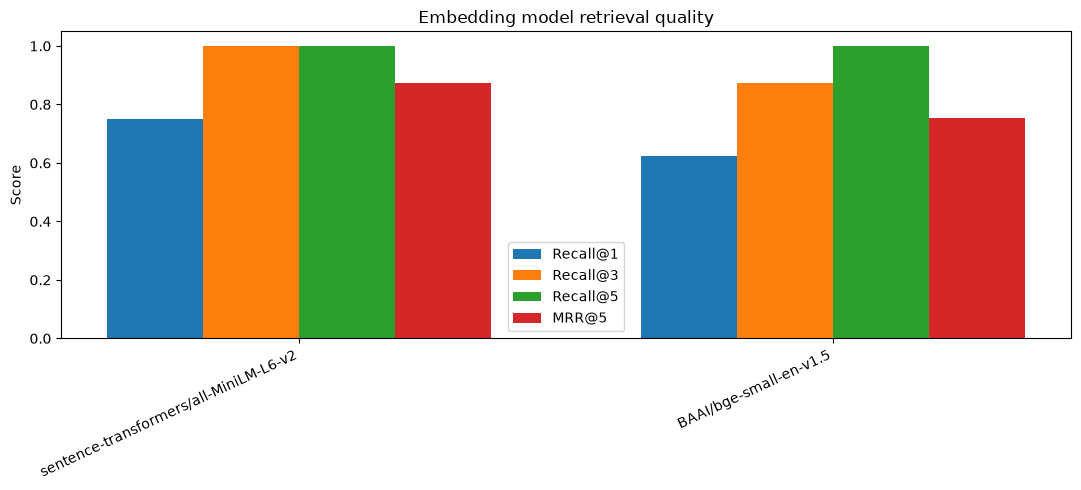

In [9]:

if not embedding_summary.empty:
    metric_names = ["Recall@1", "Recall@3", "Recall@5", "MRR@5"]

    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(embedding_summary))
    width = 0.18

    for i, metric in enumerate(metric_names):
        ax.bar(x + (i - 1.5) * width, embedding_summary[metric], width, label=metric)

    ax.set_xticks(x)
    ax.set_xticklabels(embedding_summary["model"], rotation=25, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Embedding model retrieval quality")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No embedding-model results are available yet.")



# 11. Latency vs accuracy

For production systems, a model is not automatically better because it has a higher retrieval score.

Consider:

\[
\text{Production utility} \approx
\frac{\text{retrieval quality}}
{\text{latency} + \text{cost} + \text{resource constraints}}
\]

This is not a formal universal metric; it is a decision-making principle.

The next plot helps identify models on the accuracy/latency frontier.


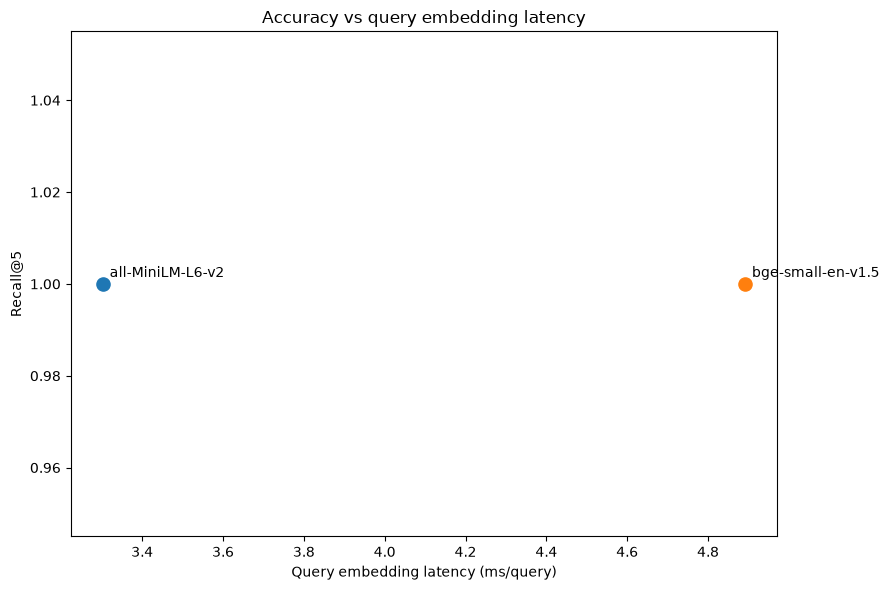

In [10]:

if not embedding_summary.empty:
    fig, ax = plt.subplots(figsize=(9, 6))

    for _, row in embedding_summary.iterrows():
        ax.scatter(
            row["query_latency_ms_per_query"],
            row["Recall@5"],
            s=90,
        )
        ax.annotate(
            row["model"].split("/")[-1],
            (
                row["query_latency_ms_per_query"],
                row["Recall@5"],
            ),
            xytext=(5, 5),
            textcoords="offset points",
        )

    ax.set_xlabel("Query embedding latency (ms/query)")
    ax.set_ylabel("Recall@5")
    ax.set_title("Accuracy vs query embedding latency")
    plt.tight_layout()
    plt.show()



# 12. Memory and model-size trade-off

Parameter count is an approximate indicator of model size, but it is not the same as actual runtime memory.

Memory depends on:

- parameter precision (FP32, FP16, INT8, etc.)
- framework overhead
- tokenizer
- batch size
- activation memory
- device
- vector index size

For the vector database, embedding dimensionality also matters because stored vector memory roughly scales with:

\[
N \times d \times bytes\_per\_value
\]

where \(N\) is the number of vectors and \(d\) is the embedding dimension.


In [11]:

if not embedding_summary.empty:
    display(
        embedding_summary[
            [
                "model",
                "parameters_M",
                "embedding_dim",
                "process_memory_MB",
                "query_latency_ms_per_query",
                "Recall@5",
                "MRR@5",
            ]
        ].sort_values("Recall@5", ascending=False)
    )


,model,parameters_M,embedding_dim,process_memory_MB,query_latency_ms_per_query,Recall@5,MRR@5
0,sentence-transformers/all-MiniLM-L6-v2,22.713216,384,633.968750,3.302400,1.0,0.875000
1,BAAI/bge-small-en-v1.5,33.360000,384,756.472656,4.891575,1.0,0.754167



# 13. Simple model-selection score

This section demonstrates a transparent decision function.

**Do not treat the weights below as universal.** They are an example for a RAG semantic-search workload where retrieval quality matters most but latency also matters.

The scoring approach:

- 70% Recall@5
- 20% MRR@5
- 10% latency efficiency

A production team should set weights from actual SLA and business requirements.


In [12]:

if not embedding_summary.empty:
    decision = embedding_summary.copy()

    latency = decision["query_latency_ms_per_query"].astype(float)
    if latency.notna().any():
        latency_efficiency = 1 - (
            (latency - latency.min()) /
            max(latency.max() - latency.min(), 1e-9)
        )
    else:
        latency_efficiency = pd.Series(0.0, index=decision.index)

    decision["latency_efficiency"] = latency_efficiency

    decision["production_score"] = (
        0.70 * decision["Recall@5"] +
        0.20 * decision["MRR@5"] +
        0.10 * decision["latency_efficiency"].fillna(0)
    )

    decision = decision.sort_values("production_score", ascending=False)

    display(
        decision[
            [
                "model",
                "Recall@5",
                "MRR@5",
                "query_latency_ms_per_query",
                "production_score",
            ]
        ]
    )

    print("Candidate recommendation:", decision.iloc[0]["model"])


,model,Recall@5,MRR@5,query_latency_ms_per_query,production_score
0,sentence-transformers/all-MiniLM-L6-v2,1.0,0.875000,3.302400,0.975000
1,BAAI/bge-small-en-v1.5,1.0,0.754167,4.891575,0.850833


Candidate recommendation: sentence-transformers/all-MiniLM-L6-v2



# 14. Optional MTEB evaluation

For a formal MTEB run, use the MTEB library against a supported model and task.

The exact API can vary across MTEB versions, so check the installed package version and current documentation before executing a large run.

Typical workflow:

1. Select the task(s) relevant to your application.
2. Load the Sentence-Transformers model.
3. Run MTEB evaluation.
4. Record task-level scores.
5. Compare with leaderboard results for context.
6. Repeat on your domain-specific dataset.

For semantic search/RAG, prioritize **retrieval tasks** instead of averaging unrelated task families into one decision.

The example below is designed as a template rather than a hard-coded claim about a particular MTEB API version.


In [13]:

# Inspect installed MTEB version and available evaluation API.
try:
    import mteb
    print("Installed MTEB version:", getattr(mteb, "__version__", "unknown"))
    print("MTEB module:", mteb)
except ImportError:
    print("MTEB is not installed.")
    print("Install with: pip install -U mteb")


MTEB is not installed.
Install with: pip install -U mteb


In [19]:

# Example MTEB-style template.
#
# Depending on your installed MTEB version, the exact task names/API may differ.
# Inspect mteb.get_tasks(...) / mteb.get_model(...) or the installed package
# documentation before running a large benchmark.
#
# Example pattern in recent MTEB releases:
#
# import mteb
# from sentence_transformers import SentenceTransformer
#
# model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
# evaluation = mteb.MTEB(tasks=["STSBenchmark"])
# results = evaluation.run(model, output_folder="mteb_results")
#
# For retrieval, select an MTEB retrieval task appropriate to your language/domain.
#
# Keep the output directory for reproducibility and compare task-level metrics.



# 15. Benchmark report

## Executive summary

The purpose of this benchmark is to identify an embedding model that provides the best balance of **semantic retrieval quality, inference latency, memory footprint, and production suitability**.

The benchmark intentionally combines:

1. **Public benchmark understanding (MTEB)** — general-purpose model capability.
2. **Local semantic-search evaluation** — performance on a controlled target dataset.
3. **Operational measurement** — latency, embedding dimension, parameter count, and process memory.

## Quantitative results

The `embedding_summary` table is the primary local benchmark result.

Report:

- Recall@1
- Recall@3
- Recall@5
- MRR@5
- query latency
- index encoding time
- embedding dimension
- model parameter count
- process memory

### Interpretation

**Recall@k**
- Higher is better.
- Low Recall@5 means relevant evidence is frequently missing from the candidate set.
- For RAG, this can directly limit answer quality.

**MRR@5**
- Higher is better.
- A model with similar Recall but higher MRR ranks useful evidence earlier.
- This can allow a smaller retrieval `k`, reducing context noise.

**Latency**
- Lower is better.
- Measure on production-like hardware and realistic batch sizes.
- API models require separate network/API latency and cost analysis.

**Memory**
- Lower is generally easier to deploy.
- But memory should be evaluated alongside accuracy; an extremely small model may not meet retrieval-quality requirements.

## Model-size trade-off

A larger embedding model often has greater representational capacity, but the practical gain must justify:

- additional compute
- larger memory footprint
- slower indexing
- slower online query embedding
- potentially larger vectors/indexes
- infrastructure cost

A smaller model can be the better production choice when its retrieval quality is close to a much larger model.

## Recommended decision process

### For a latency-sensitive production RAG

Prefer the smallest model that meets the minimum Recall@k and MRR targets.

### For high-stakes knowledge retrieval

Prefer retrieval quality first, then use reranking and filtering to control context noise.

### For very large corpora

Consider embedding dimension, indexing cost, vector storage, and query throughput in addition to benchmark scores.

## Data-backed recommendation template

After running the notebook, replace the following with the measured values:

> **Recommended model:** `<model name>`
>
> **Reason:** It achieved `<Recall@5>` Recall@5 and `<MRR@5>` MRR@5 while maintaining `<latency>` ms/query. Its quality/latency trade-off was better than `<alternative model>`, making it the preferred candidate for `<use case>`.
>
> **Main weakness:** `<weakness>`
>
> **Mitigation:** `<reranking / chunking / hybrid search / query rewriting>`
>
> **Next experiment:** Validate the winning model on a larger expert-labeled domain dataset and compare end-to-end RAG answer quality.

## Important conclusion

There is no universally optimal embedding model.

The correct production decision is the model that performs best on **your retrieval distribution under your operational constraints**. MTEB is an excellent standardized reference point, but it should complement—not replace—a domain-specific benchmark.


In [20]:

# 17. Export benchmark artifacts

output_dir = Path("embedding_benchmark_results")
output_dir.mkdir(exist_ok=True)

if not embedding_summary.empty:
    embedding_summary.to_csv(
        output_dir / "embedding_model_summary.csv",
        index=False,
    )

    for model_name, df in embedding_per_query.items():
        safe = re.sub(r"[^A-Za-z0-9_-]+", "_", model_name)
        df.to_csv(
            output_dir / f"{safe}_per_query.csv",
            index=False,
        )

tfidf_summary.to_frame("score").to_csv(
    output_dir / "tfidf_baseline_summary.csv"
)

print("Results exported to:", output_dir.resolve())


Results exported to: C:\Users\asus\OneDrive\Desktop\AI_Automation_dep\AI_Automation_dep\8-Sep-Embeddings-evaluation-(MTEB-style)\embedding_benchmark_results
